# Non-Personalized & Content-Based Recommendation Techniques

* LLM Use:
    * LLMs for planning your code is not allowed. (For example -- don't use an LLM to solve part 1 "just to see how it's done" before doing it yourself.)
    * LLMs use for large-code writing is not allowed (I.E. multiple small lines, or single long lines of code)
    * LLMS use for low-level code-lookup and debugging support is allowed with clear attribtuion (For example, using an LLM to figure ou the best way to the the average of a dataframe in pandas is _fine_)
    * LLMs should not be used in the analysis part, except for spelling and grammar support. Your words should be your own.

## Overview

this project is a series of exercises intended to explore basic recommendation techniques. Doing these exercises should:

* Prepare you to work with common tools, languages, and data formats for recsys work (circa 2025ish, the popular tools do change)
* Hone your basic data analysis skills before we do harder tasks with them.
* Give you richer experience with the _shape_ and _structure_ of recommender systems data.
* Give you practical experience with simple non-personalized and content-based approaches. While we might learn _better_ algorithms later in the semester, these simple approaches can often serve as a good way to "test the waters" to see what information seems most useful for making predictions in a domain.

As you work, make sure that you are not _speedrunning_ the project. I know it's easy to want to get the work done fast -- but an explicit part of this project is getting used to the nature of recommender system data at an intuitive level. This isn't something I can usefully teach you -- it's just something you need to see and experience for yourself. Make sure you're looking over data, trying out small tweaks and _exploring_ as you go.

## Outline

I've broken down this project into 5 core parts:

*  part 1 - basic data loading and exploration
*  part 2 - non-personalized algorithms and analysis
*  Part 3 - basic demographic analysis
*  part 4 - basic item association analysis

Most of these will call for you to implement a basic algorithm of computation, and then produce a practical result from it (often a top-10 movie list). Some questions will then ask you to follow-up with some practical evaluation in a series of short-answer questions.

## Notes:
 * All instructions are in-line in this document. We've tried to balance clarity with brevity here, which means that there might be a few instructions that we're _assuming_ are clear enough. If you're ever unclear what is expected or required of you please reach out over slack or email for clarification.
 * As _this_ document will be hard to meaningfully update after the project begins, make sure you regularly check canvas and slack for any updates, new hints or FAQs
 * While you are not required to use the pandas framework for doing this data analysis, it's commonly considered a power-tool for this sort of work, and you might find many parts of this project much easier _with_ pandas than without. I'm hoping to provide some pandas hints in lecture, and on slack, but I'm not an expert either. You are encouraged to read about pandas, and it's entirely reasonable to google around for how to perform some of these basic operations.

To start this project, make a copy of this notebook: <https://colab.research.google.com/drive/1dVdMXltAZD3pGAgqlfV7li08L8zirS2e?usp=sharing>

by clicking File --> save a copy in Drive like below. Then please work on your copy.

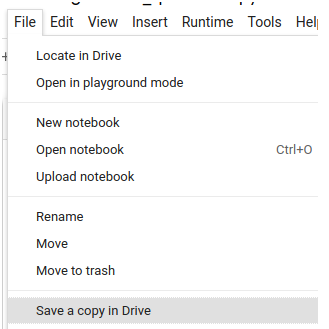

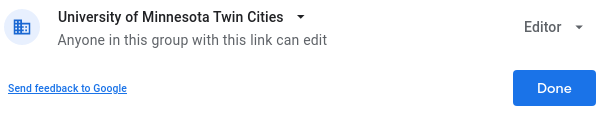


# References

1. How to use distinct on a column in pandas -- response showed me nuinque syntax as equivalent to users.
2. Why am I getting the error of merge not available with damped_average_calculation -- gave me the response that it is a series and needs to be converted to df.
3. How to convert a series to a dataframe -- gave me an example which i used throughout
4. What's the best way to compute intersection of one user set with all other user sets -- gave me an explantion to store the user set, and for every other movie we just check the number of toy story users present.


#Data loading and preperation

Note -- the first few code blocks here do a lot of required set-up. You shouldn't need to change this code, but you're free to do so if you feel like it. If those changes are important it might be worth adding a note here to draw our attention to it when reviewing your code.


In [94]:
# Get the MovieLens data
!wget -nc https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -n 'ml-1m.zip'
!cat ml-1m/README



File ‘ml-1m.zip’ already there; not retrieving.

Archive:  ml-1m.zip
SUMMARY

These files contain 1,000,209 anonymous ratings of approximately 3,900 movies 
made by 6,040 MovieLens users who joined MovieLens in 2000.

USAGE LICENSE

Neither the University of Minnesota nor any of the researchers
involved can guarantee the correctness of the data, its suitability
for any particular purpose, or the validity of results based on the
use of the data set.  The data set may be used for any research
purposes under the following conditions:

     * The user may not state or imply any endorsement from the
       University of Minnesota or the GroupLens Research Group.

     * The user must acknowledge the use of the data set in
       publications resulting from the use of the data set
       (see below for citation information).

     * The user may not redistribute the data without separate
       permission.

     * The user may not use this information for any commercial or
       revenue-bea

In [95]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [96]:
# grab the item data and prepare it a little
items = pd.read_csv("ml-1m/movies.dat",
                    delimiter="::",
                    names=["movieId", "movieName", "genres"],
                    engine='python',
                    encoding="ISO-8859-1")

In [97]:
# genres from readme
genres = [
    "Action", "Adventure", "Animation", "Children's", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical",
    "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]
# temporary matrix with columns as genres and movies as rows
genre_matrix = pd.DataFrame(0, index=items.movieId, columns=genres)
# iterate over each movie and genre
# if the genre is in the movie's set of genres, put down a 1
count = 0
for idx, row in items.iterrows():
        count = idx
        movie_genres = row['genres'].split('|')
        for genre in movie_genres:
            if genre in genres:  # Check if genre is in our list
                genre_matrix.loc[row['movieId'], genre] = 1
# merge this into items.
items = items.merge(genre_matrix, on="movieId")
display(items)

,movieId,movieName,genres,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Animation|Children's|Comedy,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3878,3948,Meet the Parents (2000),Comedy,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3879,3949,Requiem for a Dream (2000),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3880,3950,Tigerland (2000),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3881,3951,Two Family House (2000),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [98]:
user = pd.read_csv("ml-1m/users.dat",
                    delimiter="::",
                    names=["userId", "gender", "age", "occupation_code", "zip_code"],
                    engine='python',
                    encoding="ISO-8859-1")
user

,userId,gender,age,occupation_code,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


In [99]:
ratings = pd.read_csv("ml-1m/ratings.dat",
                      delimiter="::",
                      names=["userId", "itemId", "rating", "tstamp"],
                      engine='python')
ratings

,userId,itemId,rating,tstamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [100]:
# Generate a rating_matrix
ratings_matrix = ratings.pivot(index='userId', columns='itemId', values='rating')
ratings_matrix

itemId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,NaN,NaN,NaN,2.0,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
# in class exercise
# goal - produce a dataframe with the name of a movie and its average rating and sort it

avg_item_rating = ratings.groupby('itemId').mean()
avg_item_rating = avg_item_rating.merge(items, left_on='itemId', right_on='movieId')
avg_item_rating = avg_item_rating[["movieId", "movieName", "rating"]]
avg_item_rating.sort_values(by="rating", ascending=False)



,movieId,movieName,rating
3054,3280,"Baby, The (1973)",5.0
3152,3382,Song of Freedom (1936),5.0
2955,3172,Ulysses (Ulisse) (1954),5.0
3010,3233,Smashing Time (1967),5.0
744,787,"Gate of Heavenly Peace, The (1995)",5.0
...,...,...,...
834,895,Venice/Venice (1992),1.0
2034,2217,Elstree Calling (1930),1.0
2031,2213,Waltzes from Vienna (1933),1.0
2982,3202,Even Dwarfs Started Small (Auch Zwerge haben k...,1.0


# Part 1: Basic Data Exploration

Your task is to compute (or just find and record):

* How many users?
* How many items?
* How many ratings?

(Two histograms are also provided here as a helpful example)


In [102]:
# How many users?
nUsers = user['userId'].nunique()
print(nUsers)

6040


In [103]:
# How many items?
nItems = items['movieId'].nunique()
print(nItems)

3883


In [104]:
# How many ratings?
nRatings = ratings['userId'].count()
print(nRatings)

1000209


<Axes: ylabel='Frequency'>

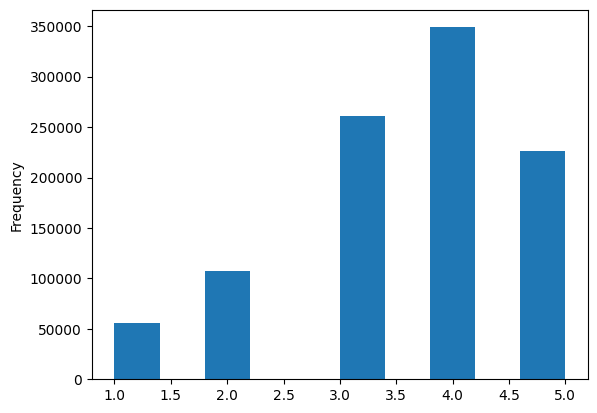

In [105]:
# Histogram of ratings (provided as a quick syntax example)
ratings['rating'].plot.hist()

userId
1        53
2       129
3        51
4        21
5       198
       ... 
6036    888
6037    202
6038     20
6039    123
6040    341
Name: rating, Length: 6040, dtype: int64



20

2314

,ratingCount
userId,
1,53
2,129
3,51
4,21
5,198
...,...
6036,888
6037,202
6038,20


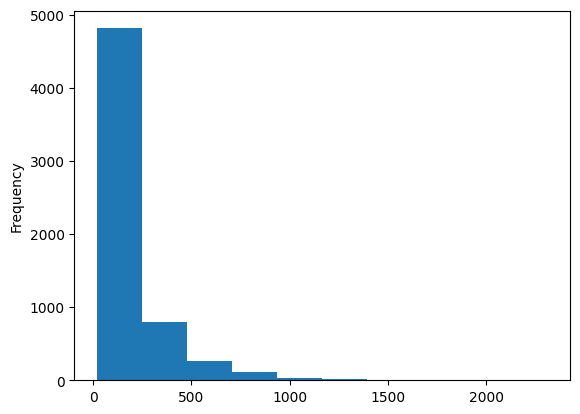

In [106]:
# the groupby function has lots of uses especially when doing a task like this one.
rating_count_by_user = ratings.groupby('userId')['rating'].count()
print(rating_count_by_user)
print()
rating_count_by_user.rename('ratingCount', inplace=True)
# histogram the values.
# number of ratings vs number of users who rated that many
rating_count_by_user.plot.hist()
# also show the min and max.
display(min(rating_count_by_user),max(rating_count_by_user))

rating_count_by_user

# Part 2: Non personalized Data Analysis

For this you'll be asked to compute some summary properties for each item, and then perform some light analysis

The algorithms you'll have to implement:

1.   average rating per movie
2.   damped average rating per movie (with damping factors 1, 10, 100, 1000)
3.   popularity (overall number of ratings) per movie
4.   percent of ratings 4 or higher (per movies)

For each of these 7 algorithms you should provide a top-10 list of movies. Please list these by movie Name (not by movieId.) and include their metric value.


In [107]:
# Top 10 movies by average ratings

avg_item_rating = ratings.groupby('itemId').mean()
avg_item_rating = avg_item_rating.merge(items, left_on='itemId', right_on='movieId')
avg_item_rating = avg_item_rating[["movieId", "movieName", "rating"]]
avg_item_rating = avg_item_rating.sort_values(by="rating", ascending=False)
avg_item_rating.head(10)

,movieId,movieName,rating
3054,3280,"Baby, The (1973)",5.0
3152,3382,Song of Freedom (1936),5.0
2955,3172,Ulysses (Ulisse) (1954),5.0
3010,3233,Smashing Time (1967),5.0
744,787,"Gate of Heavenly Peace, The (1995)",5.0
1652,1830,Follow the Bitch (1998),5.0
926,989,Schlafes Bruder (Brother of Sleep) (1995),5.0
3414,3656,Lured (1947),5.0
3367,3607,One Little Indian (1973),5.0
3635,3881,Bittersweet Motel (2000),5.0


In [108]:
# top 10 movies by damped average rating (damping factor 1)
mu = ratings['rating'].mean()
delta = 1
print("mu is:", mu)

ratings_per_movie = ratings.groupby('itemId')
rating_sum = ratings_per_movie['rating'].sum()
rating_count = ratings_per_movie['rating'].count()

damped_avg = (rating_sum + delta * mu) / (rating_count + delta)
damped_avg_df = pd.DataFrame({'itemId': damped_avg.index, 'damped_rating': damped_avg.values})

damped_avg_df = damped_avg_df.merge(items, left_on='itemId', right_on='movieId')
damped_avg_df = damped_avg_df[["movieId", "movieName", "damped_rating"]]
damped_avg_df.sort_values(by="damped_rating", ascending=False).head(10)

mu is: 3.581564453029317


,movieId,movieName,damped_rating
744,787,"Gate of Heavenly Peace, The (1995)",4.645391
51,53,Lamerica (1994),4.620174
3021,3245,I Am Cuba (Soy Cuba/Ya Kuba) (1964),4.596927
2698,2905,Sanjuro (1962),4.594022
1839,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.558953
2309,2503,"Apple, The (Sib) (1998)",4.558156
309,318,"Shawshank Redemption, The (1994)",4.554121
3010,3233,Smashing Time (1967),4.527188
802,858,"Godfather, The (1972)",4.524542
708,745,"Close Shave, A (1995)",4.519121


In [109]:
# top 10 movies by damped average rating (damping factor 10)
mu = ratings['rating'].mean()
delta = 10
print("mu is:", mu)

ratings_per_movie = ratings.groupby('itemId')
rating_sum = ratings_per_movie['rating'].sum()
rating_count = ratings_per_movie['rating'].count()

damped_avg = (rating_sum + delta * mu) / (rating_count + delta)
damped_avg_df = pd.DataFrame({'itemId': damped_avg.index, 'damped_rating': damped_avg.values})

damped_avg_df = damped_avg_df.merge(items, left_on='itemId', right_on='movieId')
damped_avg_df = damped_avg_df[["movieId", "movieName", "damped_rating"]]
damped_avg_df.sort_values(by="damped_rating", ascending=False).head(10)

mu is: 3.581564453029317


,movieId,movieName,damped_rating
309,318,"Shawshank Redemption, The (1994)",4.550208
1839,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.545166
802,858,"Godfather, The (1972)",4.520741
49,50,"Usual Suspects, The (1995)",4.511888
708,745,"Close Shave, A (1995)",4.506470
513,527,Schindler's List (1993),4.506403
1066,1148,"Wrong Trousers, The (1993)",4.497551
2698,2905,Sanjuro (1962),4.478679
1108,1198,Raiders of the Lost Ark (1981),4.474174
861,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.472533


In [110]:
# top 10 movies by damped average rating (damping factor 100)
mu = ratings['rating'].mean()
delta = 100
print("mu is:", mu)

ratings_per_movie = ratings.groupby('itemId')
rating_sum = ratings_per_movie['rating'].sum()
rating_count = ratings_per_movie['rating'].count()

damped_avg = (rating_sum + delta * mu) / (rating_count + delta)
damped_avg_df = pd.DataFrame({'itemId': damped_avg.index, 'damped_rating': damped_avg.values})

damped_avg_df = damped_avg_df.merge(items, left_on='itemId', right_on='movieId')
damped_avg_df = damped_avg_df[["movieId", "movieName", "damped_rating"]]
damped_avg_df.sort_values(by="damped_rating", ascending=False).head(10)

mu is: 3.581564453029317


,movieId,movieName,damped_rating
309,318,"Shawshank Redemption, The (1994)",4.512744
802,858,"Godfather, The (1972)",4.484355
513,527,Schindler's List (1993),4.471779
49,50,"Usual Suspects, The (1995)",4.467422
1108,1198,Raiders of the Lost Ark (1981),4.443442
1839,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.426039
253,260,Star Wars: Episode IV - A New Hope (1977),4.425479
1066,1148,"Wrong Trousers, The (1993)",4.413601
843,904,Rear Window (1954),4.398397
708,745,"Close Shave, A (1995)",4.396508


In [111]:
# top 10 movies by damped average rating (damping factor 1000)
mu = ratings['rating'].mean()
delta = 1000
print("mu is:", mu)

ratings_per_movie = ratings.groupby('itemId')
rating_sum = ratings_per_movie['rating'].sum()
rating_count = ratings_per_movie['rating'].count()

damped_avg = (rating_sum + delta * mu) / (rating_count + delta)
damped_avg_df = pd.DataFrame({'itemId': damped_avg.index, 'damped_rating': damped_avg.values})

damped_avg_df = damped_avg_df.merge(items, left_on='itemId', right_on='movieId')
damped_avg_df = damped_avg_df[["movieId", "movieName", "damped_rating"]]
damped_avg_df.sort_values(by="damped_rating", ascending=False).head(10)

mu is: 3.581564453029317


,movieId,movieName,damped_rating
309,318,"Shawshank Redemption, The (1994)",4.253041
253,260,Star Wars: Episode IV - A New Hope (1977),4.235170
802,858,"Godfather, The (1972)",4.232257
513,527,Schindler's List (1993),4.229287
1108,1198,Raiders of the Lost Ark (1981),4.222699
49,50,"Usual Suspects, The (1995)",4.180943
2557,2762,"Sixth Sense, The (1999)",4.167842
2651,2858,American Beauty (1999),4.151211
579,593,"Silence of the Lambs, The (1991)",4.136547
1848,2028,Saving Private Ryan (1998),4.130458


In [112]:
# top 10 most popular movies
ratings_per_movie = ratings.groupby('itemId')
rating_count = ratings_per_movie['rating'].count()
popular_df = pd.DataFrame({'itemId': rating_count.index, 'popularity': rating_count.values})
popular_df = popular_df.merge(items, left_on='itemId', right_on='movieId')
popular_df = popular_df[["movieId", "movieName", "popularity"]]
popular_df.sort_values(by="popularity", ascending=False).head(10)

,movieId,movieName,popularity
2651,2858,American Beauty (1999),3428
253,260,Star Wars: Episode IV - A New Hope (1977),2991
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,2990
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883
466,480,Jurassic Park (1993),2672
1848,2028,Saving Private Ryan (1998),2653
575,589,Terminator 2: Judgment Day (1991),2649
2374,2571,"Matrix, The (1999)",2590
1178,1270,Back to the Future (1985),2583
579,593,"Silence of the Lambs, The (1991)",2578


In [113]:
# top 10 movies sorted by percent of ratings 4 or higher.
ratings_per_movie = ratings.groupby('itemId')
rating_count = ratings_per_movie['rating'].count()
filtered_ratings = ratings[ratings['rating'] >= 4]
filtered_ratings_count = filtered_ratings.groupby('itemId')['rating'].count()
percent_4_plus = (filtered_ratings_count / rating_count) * 100
percent_df = pd.DataFrame({'itemId': percent_4_plus.index, 'percent_4_plus': percent_4_plus.values})
percent_df = percent_df.merge(items, left_on='itemId', right_on='movieId')
percent_df = percent_df[['movieId', 'movieName', 'percent_4_plus']]
percent_df.sort_values(by='percent_4_plus', ascending=False).head(10)


,movieId,movieName,percent_4_plus
51,53,Lamerica (1994),100.0
3414,3656,Lured (1947),100.0
129,134,Sonic Outlaws (1995),100.0
3406,3647,Running Free (2000),100.0
1330,1434,"Stranger, The (1994)",100.0
1221,1316,Anna (1996),100.0
926,989,Schlafes Bruder (Brother of Sleep) (1995),100.0
1358,1470,Rhyme & Reason (1997),100.0
1061,1139,Everything Relative (1996),100.0
134,139,Target (1995),100.0


## 2.2 Additional reporting
Please provide a histogram of average rating per movie, and popularity per movie


<Axes: ylabel='Frequency'>

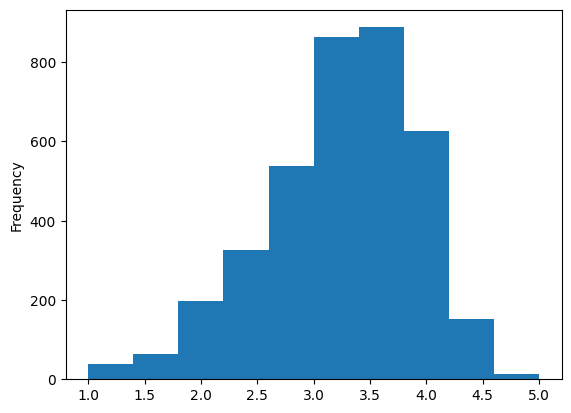

In [114]:
# histogram of average rating per movie:
avg_item_rating = ratings.groupby('itemId').mean()
avg_item_rating = avg_item_rating.merge(items, left_on='itemId', right_on='movieId')
avg_item_rating = avg_item_rating[["movieId", "movieName", "rating"]]

avg_item_rating['rating'].plot.hist()

<Axes: ylabel='Frequency'>

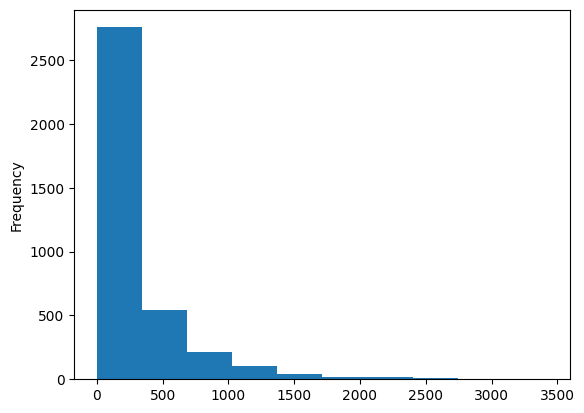

In [115]:
# histogram of movie popularity:
popular_df['popularity'].plot.hist()

## 2.3 Analysis


Question 1: What damping factor would you recommend and why?


ANS:

I would recommend a damping factor of 1000 because the ratings predominantly reflect popular movies. This helps produce more reliable rankings by reducing the influence of movies with very few ratings, resulting in recommendations that better align with overall audience preferences.


Question 2: What is your opinion of the percent-greater-than-4 algorithm. Does it seem to work? if yes, why? If no, why not and what can be done about it?


ANS:

The percentage of ratings greater than 4 does not work well because some movies that are not very popular still receive high ratings. This happens due to a small number of ratings, which can be misleading.


# Part 3: Demographic approaches.

For this part you will repeat some of the tasks done above but making the computations separately for each gender (as self-reported in the user data)

You'll be asked to compute the damped average rating for each item (split by gender) and the item popularity (split by gender). You will report this both in the "top 10" form seen above, and in a "biggest gap" form (I.E the 5 movies where the male/female average rating is most higher than the opposite gender rating)


In [116]:
# creating two dataframe for male and female ratings

ratings_with_gender = ratings.merge(user, on='userId')
male_ratings = ratings_with_gender[ratings_with_gender['gender'] == 'M']
female_ratings = ratings_with_gender[ratings_with_gender['gender'] == 'F']

In [117]:
# Top 10 most popular movies among male identified users (popularity = number of ratings)
ratings_per_movie = male_ratings.groupby('itemId')
rating_count = ratings_per_movie['rating'].count()
popular_df = pd.DataFrame({'itemId': rating_count.index, 'popularity_male': rating_count.values})
popular_df = popular_df.merge(items, left_on='itemId', right_on='movieId')
popular_df = popular_df[["movieId", "movieName", "popularity_male"]]
popular_df.sort_values(by="popularity_male", ascending=False).head(10)

,movieId,movieName,popularity_male
2628,2858,American Beauty (1999),2482
251,260,Star Wars: Episode IV - A New Hope (1977),2344
1096,1196,Star Wars: Episode V - The Empire Strikes Back...,2342
1110,1210,Star Wars: Episode VI - Return of the Jedi (1983),2230
570,589,Terminator 2: Judgment Day (1991),2193
461,480,Jurassic Park (1993),2099
1831,2028,Saving Private Ryan (1998),2078
2352,2571,"Matrix, The (1999)",2076
1436,1580,Men in Black (1997),2000
1168,1270,Back to the Future (1985),1944


In [118]:
# Top 10 most popular movies among female identified users (popularity = number of ratings)
ratings_per_movie = female_ratings.groupby('itemId')
rating_count = ratings_per_movie['rating'].count()
popular_df = pd.DataFrame({'itemId': rating_count.index, 'popularity_female': rating_count.values})
popular_df = popular_df.merge(items, left_on='itemId', right_on='movieId')
popular_df = popular_df[["movieId", "movieName", "popularity_female"]]
popular_df.sort_values(by="popularity_female", ascending=False).head(10)

,movieId,movieName,popularity_female
2503,2858,American Beauty (1999),946
2070,2396,Shakespeare in Love (1998),798
559,593,"Silence of the Lambs, The (1991)",706
2412,2762,"Sixth Sense, The (1999)",664
1087,1265,Groundhog Day (1993),658
571,608,Fargo (1996),657
1034,1210,Star Wars: Episode VI - Return of the Jedi (1983),653
1020,1196,Star Wars: Episode V - The Empire Strikes Back...,648
248,260,Star Wars: Episode IV - A New Hope (1977),647
339,356,Forrest Gump (1994),644


In [119]:
# Top 10 movies among male identified users (using damped-average-rating, damping factor 5)
mu = male_ratings['rating'].mean()
delta = 5
print("mu is:", mu)

ratings_per_movie = male_ratings.groupby('itemId')
rating_sum = ratings_per_movie['rating'].sum()
rating_count = ratings_per_movie['rating'].count()

damped_avg = (rating_sum + delta * mu) / (rating_count + delta)
damped_avg_df = pd.DataFrame({'itemId': damped_avg.index, 'damped_rating': damped_avg.values})

damped_avg_df = damped_avg_df.merge(items, left_on='itemId', right_on='movieId')
damped_avg_df = damped_avg_df[["movieId", "movieName", "damped_rating"]]
damped_avg_male = damped_avg_df.sort_values(by="damped_rating", ascending=False)
damped_avg_male.head(10)

mu is: 3.5688785290984373


,movieId,movieName,damped_rating
795,858,"Godfather, The (1972)",4.580427
1822,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.567067
2675,2905,Sanjuro (1962),4.558248
306,318,"Shawshank Redemption, The (1994)",4.557535
1098,1198,Raiders of the Lost Ark (1981),4.518153
49,50,"Usual Suspects, The (1995)",4.514796
251,260,Star Wars: Episode IV - A New Hope (1977),4.493335
508,527,Schindler's List (1993),4.488692
1056,1148,"Wrong Trousers, The (1993)",4.471255
834,904,Rear Window (1954),4.467074


In [120]:
# Top 10 movies among female identified users (using damped-average-rating, damping factor 5)
mu = female_ratings['rating'].mean()
delta = 5
print("mu is:", mu)

ratings_per_movie = female_ratings.groupby('itemId')
rating_sum = ratings_per_movie['rating'].sum()
rating_count = ratings_per_movie['rating'].count()

damped_avg = (rating_sum + delta * mu) / (rating_count + delta)
damped_avg_df = pd.DataFrame({'itemId': damped_avg.index, 'damped_rating': damped_avg.values})

damped_avg_df = damped_avg_df.merge(items, left_on='itemId', right_on='movieId')
damped_avg_df = damped_avg_df[["movieId", "movieName", "damped_rating"]]
damped_avg_female = damped_avg_df.sort_values(by="damped_rating", ascending=False)
damped_avg_female.head(10)

mu is: 3.6203660120110372


,movieId,movieName,damped_rating
667,745,"Close Shave, A (1995)",4.616767
618,670,"World of Apu, The (Apur Sansar) (1959)",4.587576
984,1148,"Wrong Trousers, The (1993)",4.568320
504,527,Schindler's List (1993),4.555003
795,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.533622
303,318,"Shawshank Redemption, The (1994)",4.531807
1031,1207,To Kill a Mockingbird (1962),4.521645
651,720,Wallace & Gromit: The Best of Aardman Animatio...,4.519461
1047,1223,"Grand Day Out, A (1992)",4.504393
48,50,"Usual Suspects, The (1995)",4.502636


In [121]:
# top 5 male-movies (I.E. movies where the average male rating is larger than the average female rating by the largest amount)
male_avg = male_ratings.groupby('itemId')['rating'].mean()
female_avg = female_ratings.groupby('itemId')['rating'].mean()

gender_avg_df = pd.DataFrame({ 'itemId': male_avg.index, 'avg_male': male_avg.values })
female_avg_df = pd.DataFrame({ 'itemId': female_avg.index, 'avg_female': female_avg.values })

gender_avg_df = gender_avg_df.merge(female_avg_df, on='itemId', how='inner')
gender_avg_df['diff_male_minus_female'] = gender_avg_df['avg_male'] - gender_avg_df['avg_female']

gender_avg_df = gender_avg_df.merge(items, left_on='itemId', right_on='movieId')
gender_avg_df = gender_avg_df[['movieId', 'movieName', 'avg_male', 'avg_female', 'diff_male_minus_female']]

gender_avg_df.sort_values(by='diff_male_minus_female', ascending=False).head(5)

,movieId,movieName,avg_male,avg_female,diff_male_minus_female
618,682,Tigrero: A Film That Was Never Made (1994),4.333333,1.0,3.333333
130,138,"Neon Bible, The (1995)",4.000000,1.0,3.000000
250,264,"Enfer, L' (1994)",3.750000,1.0,2.750000
670,760,Stalingrad (1993),3.593750,1.0,2.593750
745,874,Killer: A Journal of Murder (1995),3.428571,1.0,2.428571


In [122]:
# top 5 female-movies (I.E. movies where the average female rating is larger than the average make rating by the largest amount)
gender_avg_df['diff_female_minus_male'] = gender_avg_df['avg_female'] - gender_avg_df['avg_male']

gender_avg_df = gender_avg_df[['movieId', 'movieName', 'avg_male', 'avg_female', 'diff_female_minus_male']]
gender_avg_df.sort_values(by='diff_female_minus_male', ascending=False).head(5)

,movieId,movieName,avg_male,avg_female,diff_female_minus_male
620,687,Country Life (1994),2.000000,5.000000,3.000000
2448,2823,"Spiders, The (Die Spinnen, 1. Teil: Der Golden...",1.000000,4.000000,3.000000
2738,3136,"James Dean Story, The (1957)",1.000000,4.000000,3.000000
680,776,Babyfever (1994),1.000000,3.666667,2.666667
3164,3641,"Woman of Paris, A (1923)",2.428571,5.000000,2.571429


In [123]:
# Top 10 most popular movies among 18-24 (popularity = number of ratings)
ratings_with_gender = ratings.merge(user, on='userId')
ratings_18_24 = ratings_with_gender[(ratings_with_gender['age'] == 18)]

ratings_per_movie = ratings_18_24.groupby('itemId')
rating_count = ratings_per_movie['rating'].count()
popular_df = pd.DataFrame({'itemId': rating_count.index, 'popularity': rating_count.values})
popular_df = popular_df.merge(items, left_on='itemId', right_on='movieId')
popular_df = popular_df[["movieId", "movieName", "popularity"]]
popular_df.sort_values(by="popularity", ascending=False).head(10)

,movieId,movieName,popularity
2452,2858,American Beauty (1999),715
1022,1210,Star Wars: Episode VI - Return of the Jedi (1983),586
1008,1196,Star Wars: Episode V - The Empire Strikes Back...,579
2202,2571,"Matrix, The (1999)",567
240,260,Star Wars: Episode IV - A New Hope (1977),562
101,110,Braveheart (1995),544
1713,2028,Saving Private Ryan (1998),543
442,480,Jurassic Park (1993),541
541,589,Terminator 2: Judgment Day (1991),529
1332,1580,Men in Black (1997),514


In [124]:
# Top 10 most popular movies among 50-55 (popularity = number of ratings)

ratings_50_55 = ratings_with_gender[(ratings_with_gender['age'] == 50)]

ratings_per_movie = ratings_50_55.groupby('itemId')
rating_count = ratings_per_movie['rating'].count()
popular_df = pd.DataFrame({'itemId': rating_count.index, 'popularity': rating_count.values})
popular_df = popular_df.merge(items, left_on='itemId', right_on='movieId')
popular_df = popular_df[["movieId", "movieName", "popularity"]]
popular_df.sort_values(by="popularity", ascending=False).head(10)

,movieId,movieName,popularity
2327,2858,American Beauty (1999),248
224,260,Star Wars: Episode IV - A New Hope (1977),215
961,1196,Star Wars: Episode V - The Empire Strikes Back...,206
534,608,Fargo (1996),199
688,858,"Godfather, The (1972)",198
1033,1270,Back to the Future (1985),193
420,480,Jurassic Park (1993),193
975,1210,Star Wars: Episode VI - Return of the Jedi (1983),192
95,110,Braveheart (1995),191
1304,1617,L.A. Confidential (1997),191


In [125]:
# Top 10 damped-average movies by users age 18-24 (using damped-average-rating, damping factor 5)

mu = ratings_18_24['rating'].mean()
delta = 5
print("mu is:", mu)

ratings_per_movie = ratings_18_24.groupby('itemId')
rating_sum = ratings_per_movie['rating'].sum()
rating_count = ratings_per_movie['rating'].count()

damped_avg = (rating_sum + delta * mu) / (rating_count + delta)
damped_avg_df = pd.DataFrame({'itemId': damped_avg.index, 'damped_rating': damped_avg.values})

damped_avg_df = damped_avg_df.merge(items, left_on='itemId', right_on='movieId')
damped_avg_df = damped_avg_df[["movieId", "movieName", "damped_rating"]]
damped_avg_df.sort_values(by="damped_rating", ascending=False).head(10)

mu is: 3.5075734460814227


,movieId,movieName,damped_rating
48,50,"Usual Suspects, The (1995)",4.666349
292,318,"Shawshank Redemption, The (1994)",4.662128
1704,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.541138
1974,2324,Life Is Beautiful (La Vita è bella) (1997),4.528265
653,745,"Close Shave, A (1995)",4.527214
2452,2858,American Beauty (1999),4.514636
974,1148,"Wrong Trousers, The (1993)",4.492054
729,858,"Godfather, The (1972)",4.491973
2495,2905,Sanjuro (1962),4.466991
487,527,Schindler's List (1993),4.462053


In [126]:
# Top 10 damped-average movies by users age 50-55 (using damped-average-rating, damping factor 5)
mu = ratings_50_55['rating'].mean()
delta = 5
print("mu is:", mu)

ratings_per_movie = ratings_50_55.groupby('itemId')
rating_sum = ratings_per_movie['rating'].sum()
rating_count = ratings_per_movie['rating'].count()

damped_avg = (rating_sum + delta * mu) / (rating_count + delta)
damped_avg_df = pd.DataFrame({'itemId': damped_avg.index, 'damped_rating': damped_avg.values})

damped_avg_df = damped_avg_df.merge(items, left_on='itemId', right_on='movieId')
damped_avg_df = damped_avg_df[["movieId", "movieName", "damped_rating"]]
damped_avg_df.sort_values(by="damped_rating", ascending=False).head(10)

mu is: 3.714512346530556


,movieId,movieName,damped_rating
1606,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.594301
2473,3030,Yojimbo (1961),4.587787
925,1148,"Wrong Trousers, The (1993)",4.574047
728,913,"Maltese Falcon, The (1941)",4.556660
727,912,Casablanca (1942),4.542351
464,527,Schindler's List (1993),4.540882
688,858,"Godfather, The (1972)",4.520062
972,1207,To Kill a Mockingbird (1962),4.510413
623,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.500530
784,969,"African Queen, The (1951)",4.476524


In [127]:
# top 5 young-person movies (movies where the average age 18-24 rating is larger than the average age 50-54 rating by the largest amount)

ratings_18_24_avg = ratings_18_24.groupby('itemId')['rating'].mean()
ratings_50_55_avg = ratings_50_55.groupby('itemId')['rating'].mean()

age_avg_df = pd.DataFrame({ 'itemId': ratings_18_24_avg.index, 'avg_18_24': ratings_18_24_avg.values })
age_50_avg_df = pd.DataFrame({ 'itemId': ratings_50_55_avg.index, 'avg_50_55': ratings_50_55_avg.values })

age_avg_df = age_avg_df.merge(age_50_avg_df, on='itemId', how='inner')
# age_50_avg_df

age_avg_df['diff_18_minus_50'] = age_avg_df['avg_18_24'] - age_avg_df['avg_50_55']
# age_50_avg_df

age_avg_df = age_avg_df.merge(items, left_on='itemId', right_on='movieId')
age_avg_df = age_avg_df[['movieId', 'movieName', 'avg_18_24', 'avg_50_55', 'diff_18_minus_50']]

age_avg_df.sort_values(by='diff_18_minus_50', ascending=False).head(5)

,movieId,movieName,avg_18_24,avg_50_55,diff_18_minus_50
2509,3205,Black Sunday (La Maschera Del Demonio) (1960),5.000000,1.000000,4.000000
2358,3021,"Funhouse, The (1981)",4.800000,1.333333,3.466667
1028,1310,Hype! (1996),4.000000,1.000000,3.000000
1341,1743,Arguing the World (1996),5.000000,2.500000,2.500000
2999,3843,Sleepaway Camp (1983),3.428571,1.000000,2.428571


In [128]:
# top 5 young-person movies (avg age 18-24 rating much higher than avg age 50-55),
# only keeping movies with at least 50 ratings from BOTH age groups

ratings_18_24_avg = ratings_18_24.groupby('itemId')['rating'].mean()
ratings_18_24_cnt = ratings_18_24.groupby('itemId')['rating'].count()

ratings_50_55_avg = ratings_50_55.groupby('itemId')['rating'].mean()
ratings_50_55_cnt = ratings_50_55.groupby('itemId')['rating'].count()

age_avg_df = pd.DataFrame({ 'itemId': ratings_18_24_avg.index, 'avg_18_24': ratings_18_24_avg.values, 'cnt_18_24': ratings_18_24_cnt.values})
age_50_avg_df = pd.DataFrame({ 'itemId': ratings_50_55_avg.index, 'avg_50_55': ratings_50_55_avg.values, 'cnt_50_55': ratings_50_55_cnt.values})

age_avg_df = age_avg_df.merge(age_50_avg_df, on='itemId', how='inner')

age_avg_df['diff_18_minus_50'] = age_avg_df['avg_18_24'] - age_avg_df['avg_50_55']

age_avg_df = age_avg_df[(age_avg_df['cnt_18_24'] >= 50) & (age_avg_df['cnt_50_55'] >= 50)]
age_avg_df = age_avg_df.merge(items, left_on='itemId', right_on='movieId')
age_avg_df = age_avg_df[['movieId', 'movieName', 'avg_18_24', 'avg_50_55', 'diff_18_minus_50', 'cnt_18_24', 'cnt_50_55']]

age_avg_df.sort_values(by='diff_18_minus_50', ascending=False).head(5)

,movieId,movieName,avg_18_24,avg_50_55,diff_18_minus_50,cnt_18_24,cnt_50_55
281,2710,"Blair Witch Project, The (1999)",3.130435,2.145455,0.984980,345,55
92,1089,Reservoir Dogs (1992),4.198020,3.491525,0.706494,303,59
196,1732,"Big Lebowski, The (1998)",4.050781,3.422535,0.628246,256,71
203,1923,There's Something About Mary (1998),3.939394,3.312500,0.626894,330,64
255,2395,Rushmore (1998),3.948012,3.339623,0.608390,327,53


## 3.2 Analysis
In your opinion, based on your results above, does demographic personalization based on self-reported gender seem to be a useful approach for recommending on MovieLens? Why, or why not?

In your opinion, based on your results above, does demographic personalization based on age (18–24 vs 50–55) seem to be a useful approach for recommending on MovieLens? Why, or why not?


ANS 1:

Demographic personalisation based on gender is useful and can be used for recommending, as there are movies that are more appealing to different genders and could be used for recommendation. This shows the general liking that each gender has watched and liked the most. Instead of recommending just highly rated movies, we can add a little personalized recommendation based on gender.

ANS 2:

Yes, demographic personalization based on age seems to be a useful approach for recommendation, as we can see that there are movies that are more appealing to a younger crowd and some movies for the elderly. Even though there are overlaps, which is natural as movies can be watched by anybody, those movies would be a safer recommendation when age isn't known. If age is known, then we can recommend movies that are highly rated within that age group.


# Part 4 Basic Item Association Recommendation

In this section you'll implement some basic item association techniques to answer the following questions:

* What is the top movie for someone who has seen "Toy Story" (movie Id 1) by co-occurrence: Calculate movies that most often occur using the $\frac{|U_{i_1} \cap U_{i_2}|}{|U_{i_1}|}$ equation (I.E. the number of users watching both items, divided by the number of users who watched toy story overall). (show the top-10 movies)

* Calculate the Pearson correlation between the ratings of toy story and each other movie, then report the top-5 by high correlation. (Do not include toy story itself)

* What is the top movie for someone who has seen "Toy Story" (movie Id 1) by lift: Calculate lift between toy story and each other movie using the $\frac{P(i_1,i_2)}{P(i_1)P(i_2)}$ equation, where $P(i)$ is the fraction of users who watched/rated movie $i$ and $P(i_1,i_2)$ is the fraction of users who watched/rated both movies. (Only include movies where $|U_{i_1} \cap U_{i_2}| \ge 50$.) (show the top-5 movies, do not include toy story itself)


In [129]:
# For each movie -- compute it's co-occurance with toy story

# Show the top-5 movies by co-occurance

toy_story_users = ratings[ratings['itemId'] == 1]['userId'].unique()
num_toy_story_users = len(toy_story_users)

toy_story_users_ratings = ratings[ratings['userId'].isin(toy_story_users)]
# toy_story_users_ratings

# count the number of unique toy story users who have rated other movies
cooccurrence_count = (
    toy_story_users_ratings
    .groupby('itemId')['userId']
    .nunique()
)
cooccurrence_count

cooccurrence_score = cooccurrence_count / num_toy_story_users
cooccurrence_df = pd.DataFrame({
    'itemId': cooccurrence_score.index,
    'cooccurrence_score': cooccurrence_score.values
})

cooccurrence_df = cooccurrence_df[cooccurrence_df['itemId'] != 1]
cooccurrence_df = cooccurrence_df.merge(
    items, left_on='itemId', right_on='movieId'
)
top10_cooccurrence = (
    cooccurrence_df[['movieId', 'movieName', 'cooccurrence_score']]
    .sort_values(by='cooccurrence_score', ascending=False)
    .head(10)
)

top10_cooccurrence


,movieId,movieName,cooccurrence_score
2556,2858,American Beauty (1999),0.678382
1047,1196,Star Wars: Episode V - The Empire Strikes Back...,0.670679
245,260,Star Wars: Episode IV - A New Hope (1977),0.665383
1114,1265,Groundhog Day (1993),0.660087
1119,1270,Back to the Future (1985),0.640828
2284,2571,"Matrix, The (1999)",0.631199
1061,1210,Star Wars: Episode VI - Return of the Jedi (1983),0.630236
1382,1580,Men in Black (1997),0.628310
1770,2028,Saving Private Ryan (1998),0.605200
558,589,Terminator 2: Judgment Day (1991),0.603274


In [130]:
# For each movie -- compute it's pearson correlation with toy story

# Show the top-5 movies by correlation

ratings_matrix = ratings.pivot(index='userId', columns='itemId', values='rating')
toy_story_ratings = ratings_matrix[1]

pearson_corr = ratings_matrix.corrwith(toy_story_ratings)

pearson_df = pd.DataFrame({
    'itemId': pearson_corr.index,
    'pearson_corr': pearson_corr.values
})

pearson_df = pearson_df[pearson_df['itemId'] != 1]

pearson_df = pearson_df.merge(items, left_on='itemId', right_on='movieId')

top5_pearson = (
    pearson_df[['movieId', 'movieName', 'pearson_corr']]
    .sort_values(by='pearson_corr', ascending=False)
    .head(5)
)

top5_pearson

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,movieId,movieName,pearson_corr
675,706,Sunset Park (1996),1.0
815,874,Killer: A Journal of Murder (1995),1.0
921,985,Small Wonders (1996),1.0
2745,2955,Penitentiary II (1982),1.0
827,887,Talk of Angels (1998),1.0


In [131]:
# For each movie -- compute Lift with toy story

# Show the top-5 movies by Lift, with a minimum co-raters filter (>= 50)

toy_id = 1
min_coraters = 50

N = ratings['userId'].nunique()

toy_users = ratings[ratings['itemId'] == toy_id]['userId'].unique()
toy_count = len(toy_users)
p_toy = toy_count / N

movie_user_count = ratings.groupby('itemId')['userId'].nunique()

toy_users_ratings = ratings[ratings['userId'].isin(toy_users)]
corater_count = toy_users_ratings.groupby('itemId')['userId'].nunique()

lift_df = pd.DataFrame({
    'itemId': movie_user_count.index,
    'movie_user_count': movie_user_count.values
})

lift_df = lift_df.merge(
    corater_count.reset_index(name='corater_count'),
    on='itemId',
    how='left'
)

lift_df['corater_count'] = lift_df['corater_count'].fillna(0).astype(int)

lift_df = lift_df[lift_df['itemId'] != toy_id]
lift_df = lift_df[lift_df['corater_count'] >= min_coraters]

lift_df['p_i2'] = lift_df['movie_user_count'] / N
lift_df['p_joint'] = lift_df['corater_count'] / N
lift_df['lift'] = lift_df['p_joint'] / (p_toy * lift_df['p_i2'])

lift_df = lift_df.merge(items, left_on='itemId', right_on='movieId')

top5_lift = (
    lift_df[['movieId', 'movieName', 'corater_count', 'lift']]
    .sort_values(by='lift', ascending=False)
    .head(5)
)

top5_lift


,movieId,movieName,corater_count,lift
11,13,Balto (1995),88,2.584925
355,575,"Little Rascals, The (1994)",95,2.581905
1147,2089,"Rescuers Down Under, The (1990)",212,2.579517
1118,2048,"Great Mouse Detective, The (1986)",115,2.552860
464,881,First Kid (1996),67,2.530373
